In [1]:
#for this script to work and acquire a single pulse image (nr of total triggers=1), disconnect the inhibit from the back of the delay generator
from DEigerClient3 import DEigerClient

url = "http://169.254.254.1/monitor/api/1.8.0/images/monitor"
DCU_IP = '169.254.254.1'
ec = DEigerClient(DCU_IP)

In [2]:
ec.listDetectorCommands()

['abort',
 'arm',
 'cancel',
 'check_connections',
 'disarm',
 'hv_enabled',
 'hv_reset',
 'initialize',
 'trigger']

In [3]:
ec.listDetectorConfigParams()

['auto_summation',
 'beam_center_x',
 'beam_center_y',
 'bit_depth_image',
 'bit_depth_readout',
 'chi_increment',
 'chi_start',
 'compression',
 'count_time',
 'counting_mode',
 'countrate_correction_applied',
 'countrate_correction_count_cutoff',
 'countrate_correction_table',
 'data_collection_date',
 'description',
 'detector_distance',
 'detector_number',
 'detector_orientation',
 'detector_readout_time',
 'detector_translation',
 'eiger_fw_version',
 'extg_mode',
 'fast_arm',
 'flatfield',
 'flatfield_correction_applied',
 'frame_count_time',
 'frame_time',
 'incident_energy',
 'incident_particle_type',
 'instrument_name',
 'kappa_increment',
 'kappa_start',
 'mask_to_zero',
 'nexpi',
 'nimages',
 'ntrigger',
 'number_of_excluded_pixels',
 'omega_increment',
 'omega_start',
 'phi_increment',
 'phi_start',
 'pixel_mask',
 'pixel_mask_applied',
 'roi_bit_depth',
 'roi_mode',
 'roi_y_size',
 'sample_name',
 'sensor_material',
 'sensor_thickness',
 'software_version',
 'source_name',

In [4]:
ec.detectorConfig('incident_energy')

{'access_mode': 'rw',
 'allowed_values': [200000,
  160000,
  120000,
  100000,
  80000,
  60000,
  40000,
  30000],
 'unit': 'eV',
 'value': 40000.0,
 'value_type': 'float'}

In [5]:
ec.fileWriterConfig('mode')

{'access_mode': 'rw',
 'allowed_values': ['enabled', 'disabled'],
 'value': 'enabled',
 'value_type': 'string'}

In [6]:
filename = 'data_1pulse'
ec.sendDetectorCommand('disarm')
ec.setDetectorConfig('trigger_mode', 'ints')
ec.setDetectorConfig('incident_energy', 40000)  # Ev
ec.setDetectorConfig('ntrigger', 1)  # ntrigger must be set to 1 for extg mode
ec.setDetectorConfig('nimages', 2)  # nimage must be even for extg mode
ec.setFileWriterConfig('nimages_per_file', 2)
ec.setDetectorConfig('nexpi', 1)  # expi, number of total triggers
ec.setDetectorConfig('trigger_mode', 'extg')  # external trigger gatted mode
ec.setDetectorConfig('counting_mode', 'normal')
ec.setDetectorConfig('extg_mode', 'double')  # this is to set pump probe
ec.setDetectorConfig('countrate_correction_applied', False)
ec.setMonitorConfig('mode', 'enabled')
ec.sendFileWriterCommand('clear')
ec.setMonitorConfig('buffer_size', 100)
    # string 'False' to boolean False
ec.setDetectorConfig('count_time', 1)
ec.setDetectorConfig('frame_time', 1)
ec.setFileWriterConfig('name_pattern', 'data_1pulse')
ec.setFileWriterConfig('compression_enabled', True)
ec.setFileWriterConfig('mode', 'enabled')
ec.sendDetectorCommand('disarm')

{'sequence id': 8890}

In [7]:

ec.sendDetectorCommand('arm')


{'sequence id': 8891}

In [8]:
ec.sendDetectorCommand('disarm')

{'sequence id': 8891}

In [9]:
import io
import h5py
import requests
import numpy as np
import matplotlib.pyplot as plt
import hdf5plugin

In [10]:
url = 'http://169.254.254.1/data/'+filename+"_data_000001.h5"
hf = h5py.File(io.BytesIO(requests.get(url).content), "r+")

In [11]:
np.array(hf['entry']['data']['data'])

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint16)

In [12]:
data = hf['entry']['data']['data'][()]
    # print('all the data, hf[entry][data][data][()] : ', data)
even = np.array(data[0])
odd = data[1]

In [ ]:
even

In [ ]:
np.amax(even-odd)

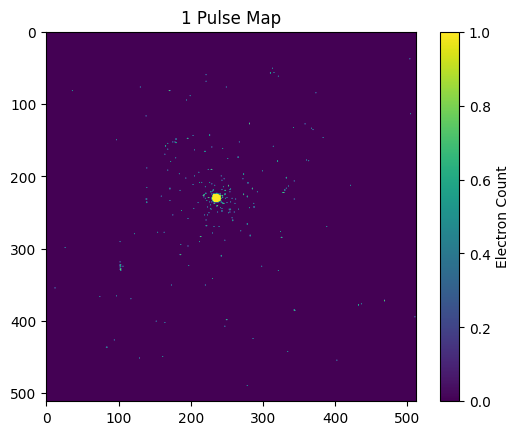

In [15]:
%matplotlib inline
plt.close('all')
plt.imshow(odd, vmin=0, vmax=1)
plt.title('1 Pulse Map')
plt.colorbar(label='Electron Count')

In [ ]:
plt.close('all')
%matplotlib widget
plt.imshow(odd-even, vmin=-1, vmax=1, cmap='bwr')